In [24]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [25]:
train_df = pd.read_csv("C:/Users/HP/OneDrive/PY DS pr/DL Projects/MedAssist-AI/backend/ml/datasets/Training.csv")
test_df = pd.read_csv("C:/Users/HP/OneDrive/PY DS pr/DL Projects/MedAssist-AI/backend/ml/datasets/Testing.csv")

In [26]:
if "Unnamed: 133" in train_df.columns:
    train_df.drop(columns=["Unnamed: 133"], inplace=True)

if "Unnamed: 133" in test_df.columns:
    test_df.drop(columns=["Unnamed: 133"], inplace=True)

In [27]:
X_train = train_df.drop("prognosis", axis=1)
y_train = train_df["prognosis"]

X_test = test_df.drop("prognosis", axis=1)
y_test = test_df["prognosis"]

In [28]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)


In [29]:
joblib.dump(
    label_encoder,
    "../saved_models/label_encoder.pkl"
)

['../saved_models/label_encoder.pkl']

In [30]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}

In [31]:
import time

results = []

trained_models = {}

for name, model in models.items():

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    start = time.time()

    y_pred = model.predict(X_test)

    prediction_time = time.time() - start

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": train_time,
        "Prediction Time": prediction_time
    })

    print("="*70)
    print(name)
    print("="*70)

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         1
          17 

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
4,KNN,1.00000,1.000000,1.00000,1.00000,0.012241,0.017806
3,Logistic Regression,1.00000,1.000000,1.00000,1.00000,0.383657,0.000000
5,Naive Bayes,1.00000,1.000000,1.00000,1.00000,0.026688,0.007254
0,Decision Tree,0.97619,0.988095,0.97619,0.97619,0.090621,0.000000
1,Random Forest,0.97619,0.988095,0.97619,0.97619,0.902341,0.013586
2,Extra Trees,0.97619,0.988095,0.97619,0.97619,1.096651,0.008395


In [33]:
import joblib

joblib.dump(
    trained_models["KNN"],
    "../saved_models/disease_model.pkl"
)

joblib.dump(
    label_encoder,
    "../saved_models/label_encoder.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [34]:
import joblib

joblib.dump(
    X_train.columns.tolist(),
    "../saved_models/symptoms.pkl"
)

print("Symptoms saved successfully!")

Symptoms saved successfully!


In [35]:
import joblib

model = joblib.load("../saved_models/disease_model.pkl")
label_encoder = joblib.load("../saved_models/label_encoder.pkl")

sample = X_test.iloc[[0]]

prediction = model.predict(sample)

predicted = label_encoder.inverse_transform(prediction)[0]
actual = label_encoder.inverse_transform([y_test[0]])[0]

print("Predicted Disease :", predicted)
print("Actual Disease    :", actual)

Predicted Disease : Fungal infection
Actual Disease    : Fungal infection


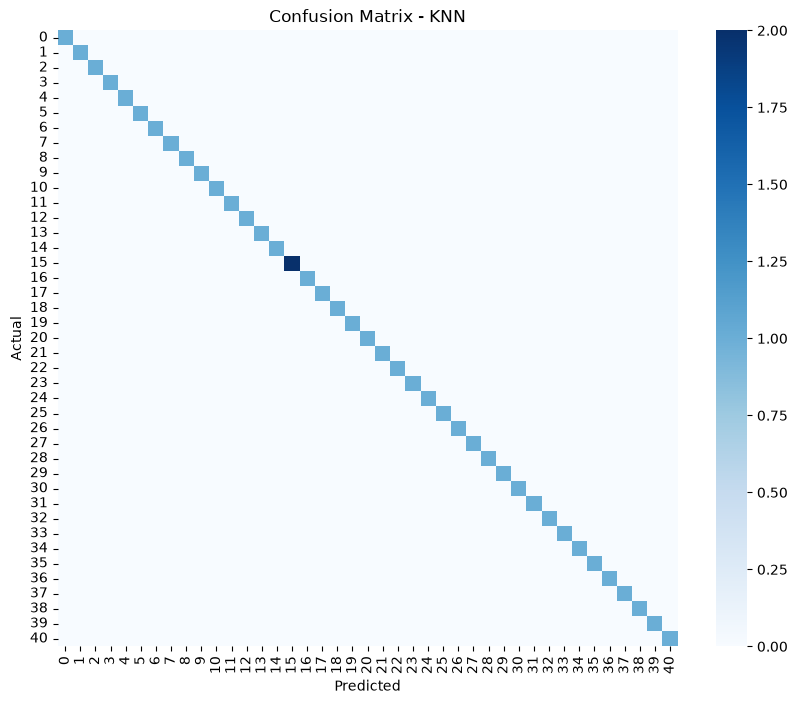

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

pred = trained_models["KNN"].predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
import pandas as pd

importance = pd.DataFrame({
    "Symptom": X_train.columns,
    "Importance": trained_models["Random Forest"].feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance.head(20)

,Symptom,Importance
97,muscle_pain,0.019514
0,itching,0.016854
33,dark_urine,0.015853
25,high_fever,0.015595
98,altered_sensorium,0.014875
14,fatigue,0.014580
34,nausea,0.014471
41,mild_fever,0.014310
43,yellowing_of_eyes,0.014072
106,family_history,0.013757


<Axes: ylabel='Symptom'>

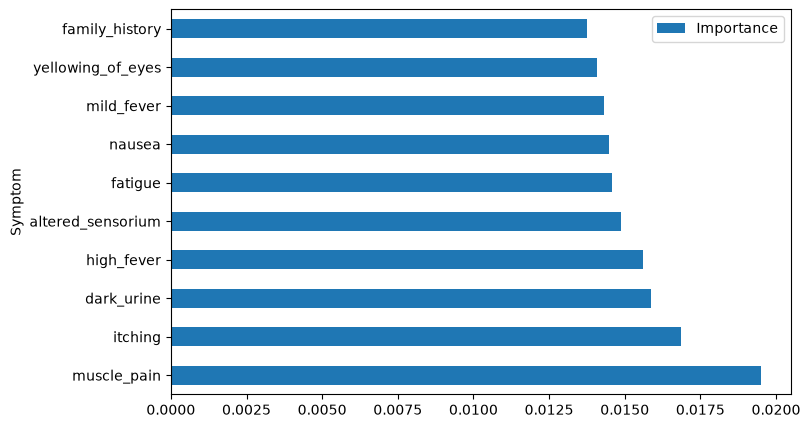

In [38]:
importance.head(10).plot.barh(
    x="Symptom",
    y="Importance",
    figsize=(8,5)
)

In [40]:
results_df.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
4,KNN,1.00000,1.000000,1.00000,1.00000,0.012241,0.017806
3,Logistic Regression,1.00000,1.000000,1.00000,1.00000,0.383657,0.000000
5,Naive Bayes,1.00000,1.000000,1.00000,1.00000,0.026688,0.007254
0,Decision Tree,0.97619,0.988095,0.97619,0.97619,0.090621,0.000000
1,Random Forest,0.97619,0.988095,0.97619,0.97619,0.902341,0.013586
2,Extra Trees,0.97619,0.988095,0.97619,0.97619,1.096651,0.008395
